# Trajectory Inference: Shaped Double Launch (RID 74108)

Simulation-based trajectory inference for the `LMTInterferometryWithShapedDoubleLaunch` pulse sequence, extracted from ARTIQ run **RID 74108** (2026-06-10). Built from the `true_trajectory_double_launch.ipynb` template.

In [1]:
# Add auto reload:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
from scipy import constants as scipy_constants
import version_info as vs

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator

In [3]:
pulse_sequence = [  [    [      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0    ],    [      4936,      2690399,      2736543,      2945087,      3025086,      3092085,      3172084,      3239083,      3319082,      3386081,      3466080,      3533079,      3613078,      8180077,      8247076,      8327075,      8394074,      8474073,      8541072,      8621071,      8688070,      8768069,      8835068,      8915067,      8982066,      9067247,      10853791,      10909575,      11217431,      11297430,      11364429,      11444428,      11511427,      11591426,      11658425,      11738424,      11805423,      11885422,      11952421,      12032420,      12099419,      12179418,      12246417,      12326416,      12393415,      12473414,      12540413,      12620412,      12687411,      12767410,      12834409,      12914408,      12981407,      13061406,      13128405,      13208404,      13275403,      13355402,      13422401,      13502400,      13569399,      13649398,      13716397,      13796396,      13863395,      13943394,      14010393,      14140400,      14220399,      14287398,      14367397,      14434396,      14514395,      14581394,      14661393,      14728392,      14808391,      14875390,      14955389,      15022388,      15102387,      15169386,      15249385,      15316384,      15396383,      15463382,      15543381,      15610380,      15690379,      15757378,      15837377,      15904376,      15984375,      16051374,      16131373,      16198372,      16278371,      16345370,      16425369,      16492368,      16572367,      16639366,      16719365,      16786364,      16866363,      16933362,      17221167,      17339015,      17427542,      17735399,      17815398,      17882397,      17962396,      18029395,      18109394,      18176393,      18256392,      18323391,      18403390,      18470389,      18550388,      18617387,      18697386,      18764385,      18844384,      18911383,      18991382,      19058381,      19138380,      19205379,      19285378,      19352377,      19432376,      19499375,      19579374,      19646373,      19726372,      19793371,      19873370,      19940369,      20020368,      20087367,      20167366,      20234365,      20314364,      20381363,      20461362,      20528361,      20658368,      20738367,      20805366,      20885365,      20952364,      21032363,      21099362,      21179361,      21246360,      21326359,      21393358,      21473357,      21540356,      21620355,      21687354,      21767353,      21834352,      21914351,      21981350,      22061349,      22128348,      22208347,      22275346,      22355345,      22422344,      22502343,      22569342,      22649341,      22716340,      22796339,      22863338,      22943337,      23010336,      23090335,      23157334,      23237333,      23304332,      23384331,      23451330,      23739127,      23860647    ],    [      380000,      34000,      200000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      30555,      34000,      100000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      100000,      68000,      100000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      100000,      34000    ],    [      80000000,      79972625,      80032357,      79987049,      80004873,      80003785,      79988137,      80020521,      79971401,      80037257,      79954665,      80053993,      79937929,      80114853,      79893605,      80098117,      79910341,      80081381,      79927077,      80064645,      79943813,      80047909,      79960550,      80031173,      79977286,      80015155,      79969805,      80022410,      79983700,      80008223,      80000436,      79991487,      80017172,      79974751,      80033908,      79958015,      80050644,      79941279,      80067380,      79924542,      80084116,      79907806,      80100852,      79891070,      80117588,      79874334,      80134324,      79857598,      80151060,      79840862,      80167796,      79824126,      80184532,      79807390,      80201268,      79790654,      80218004,      79773918,      80234740,      79757182,      80251476,      79740446,      80268212,      79723710,      80284948,      79706974,      80301684,      80299659,      79710863,      80278795,      79731727,      80257931,      79752591,      80237067,      79773455,      80216203,      79794319,      80195339,      79815183,      80174475,      79836047,      80153611,      79856911,      80132747,      79877775,      80111883,      79898639,      80091020,      79919503,      80070156,      79940367,      80049292,      79961231,      80028428,      79982095,      80007564,      80002958,      79986700,      80023822,      79965836,      80044686,      79944972,      80065550,      79924108,      80086414,      79903244,      80110829,      79878548,      80113727,      79891983,      80099739,      79908719,      80083003,      79925455,      80066267,      79942191,      80049531,      79958927,      80032795,      79975663,      80016059,      79992399,      79999323,      80009135,      79982587,      80025871,      79965851,      80042607,      79949115,      80059343,      79932379,      80076079,      79915643,      80092815,      79898907,      80109551,      79882171,      80126288,      79865435,      80143024,      79848699,      80159760,      79831963,      80176496,      79815227,      80193232,      79798491,      80209968,      80208142,      79802380,      80187278,      79823244,      80166414,      79844108,      80145551,      79864972,      80124687,      79885836,      80103823,      79906700,      80082959,      79927564,      80062095,      79948428,      80041231,      79969291,      80020367,      79990155,      79999503,      80011019,      79978639,      80031883,      79957775,      80052747,      79936911,      80073611,      79916047,      80094475,      79895183,      80115339,      79874319,      80136203,      79853455,      80157067,      79832591,      80177931,      79811727,      80201346,      79787249    ],    [      200000000,      200005800,      200000000,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200000500,      200005800,      200000500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200000500,      200005800,      200000500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200000500,      200005800    ],    [      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200    ],    [      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2    ]  ],  [    [      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0,      1,      0    ],    [      4936,      2690399,      2736543,      2945087,      3025086,      3092085,      3172084,      3239083,      3319082,      3386081,      3466080,      3533079,      3613078,      8180077,      8247076,      8327075,      8394074,      8474073,      8541072,      8621071,      8688070,      8768069,      8835068,      8915067,      8982066,      9067247,      10853791,      10909575,      11217431,      11297430,      11364429,      11444428,      11511427,      11591426,      11658425,      11738424,      11805423,      11885422,      11952421,      12032420,      12099419,      12179418,      12246417,      12326416,      12393415,      12473414,      12540413,      12620412,      12687411,      12767410,      12834409,      12914408,      12981407,      13061406,      13128405,      13208404,      13275403,      13355402,      13422401,      13502400,      13569399,      13649398,      13716397,      13796396,      13863395,      13943394,      14010393,      14140400,      14220399,      14287398,      14367397,      14434396,      14514395,      14581394,      14661393,      14728392,      14808391,      14875390,      14955389,      15022388,      15102387,      15169386,      15249385,      15316384,      15396383,      15463382,      15543381,      15610380,      15690379,      15757378,      15837377,      15904376,      15984375,      16051374,      16131373,      16198372,      16278371,      16345370,      16425369,      16492368,      16572367,      16639366,      16719365,      16786364,      16866363,      16933362,      17221167,      17339015,      17427542,      17735399,      17815398,      17882397,      17962396,      18029395,      18109394,      18176393,      18256392,      18323391,      18403390,      18470389,      18550388,      18617387,      18697386,      18764385,      18844384,      18911383,      18991382,      19058381,      19138380,      19205379,      19285378,      19352377,      19432376,      19499375,      19579374,      19646373,      19726372,      19793371,      19873370,      19940369,      20020368,      20087367,      20167366,      20234365,      20314364,      20381363,      20461362,      20528361,      20658368,      20738367,      20805366,      20885365,      20952364,      21032363,      21099362,      21179361,      21246360,      21326359,      21393358,      21473357,      21540356,      21620355,      21687354,      21767353,      21834352,      21914351,      21981350,      22061349,      22128348,      22208347,      22275346,      22355345,      22422344,      22502343,      22569342,      22649341,      22716340,      22796339,      22863338,      22943337,      23010336,      23090335,      23157334,      23237333,      23304332,      23384331,      23451330,      23739127,      23860647    ],    [      380000,      34000,      200000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      30555,      34000,      100000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      100000,      68000,      100000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      55000,      68000,      100000,      34000    ],    [      80000000,      79972625,      80032357,      79987049,      80004873,      80003785,      79988137,      80020521,      79971401,      80037257,      79954665,      80053993,      79937929,      80114853,      79893605,      80098117,      79910341,      80081381,      79927077,      80064645,      79943813,      80047909,      79960550,      80031173,      79977286,      80015155,      79969805,      80022410,      79983700,      80008223,      80000436,      79991487,      80017172,      79974751,      80033908,      79958015,      80050644,      79941279,      80067380,      79924542,      80084116,      79907806,      80100852,      79891070,      80117588,      79874334,      80134324,      79857598,      80151060,      79840862,      80167796,      79824126,      80184532,      79807390,      80201268,      79790654,      80218004,      79773918,      80234740,      79757182,      80251476,      79740446,      80268212,      79723710,      80284948,      79706974,      80301684,      80299659,      79710863,      80278795,      79731727,      80257931,      79752591,      80237067,      79773455,      80216203,      79794319,      80195339,      79815183,      80174475,      79836047,      80153611,      79856911,      80132747,      79877775,      80111883,      79898639,      80091020,      79919503,      80070156,      79940367,      80049292,      79961231,      80028428,      79982095,      80007564,      80002958,      79986700,      80023822,      79965836,      80044686,      79944972,      80065550,      79924108,      80086414,      79903244,      80110829,      79878548,      80113727,      79891983,      80099739,      79908719,      80083003,      79925455,      80066267,      79942191,      80049531,      79958927,      80032795,      79975663,      80016059,      79992399,      79999323,      80009135,      79982587,      80025871,      79965851,      80042607,      79949115,      80059343,      79932379,      80076079,      79915643,      80092815,      79898907,      80109551,      79882171,      80126288,      79865435,      80143024,      79848699,      80159760,      79831963,      80176496,      79815227,      80193232,      79798491,      80209968,      80208142,      79802380,      80187278,      79823244,      80166414,      79844108,      80145551,      79864972,      80124687,      79885836,      80103823,      79906700,      80082959,      79927564,      80062095,      79948428,      80041231,      79969291,      80020367,      79990155,      79999503,      80011019,      79978639,      80031883,      79957775,      80052747,      79936911,      80073611,      79916047,      80094475,      79895183,      80115339,      79874319,      80136203,      79853455,      80157067,      79832591,      80177931,      79811727,      80201346,      79787249    ],    [      200000500,      200005800,      200000000,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200000500,      200005800,      200000500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200000500,      200005800,      200000500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200001500,      200005800,      200000500,      200005800    ],    [      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200,      99476200    ],    [      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2,      2    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ],  [    [      -1    ]  ]]

In [4]:
(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    switch_hz,
    delivery_hz,
    delivery_setpoint
) = pulse_sequence[0]

is_up = np.array(is_up)
start_times_mu = np.array(start_times_mu)
durations_mu = np.array(durations_mu)
opll_hz = np.array(opll_hz)
switch_hz = np.array(switch_hz)
delivery_hz = np.array(delivery_hz)
delivery_setpoint = np.array(delivery_setpoint)

In [5]:
# Manually specify which durations are pi pulses and which are pi/2
is_pi_pulse = lambda d: d > 50000e-9

In [6]:
# Cut after the launch

t_launch_finished = 5e-3

is_before_launch = start_times_mu * 1e-9 < t_launch_finished

is_up = is_up[is_before_launch]
start_times_mu = start_times_mu[is_before_launch]
durations_mu = durations_mu[is_before_launch]
opll_hz = opll_hz[is_before_launch]
switch_hz = switch_hz[is_before_launch]
delivery_hz = delivery_hz[is_before_launch]
delivery_setpoint = delivery_setpoint[is_before_launch]

In [7]:
# --- HACKY AUTO-CALIBRATION (a warning is emitted at runtime) ---
# alpha (probe-shift coefficient) and v0 (initial atom velocity) used to be
# hand-tuned magic numbers. Instead we now back them out of the lab pulse dump:
# alpha from how the up-beam pulses sit relative to each other vs their Rabi
# frequency, and v0 from the residual up/down detuning once alpha is applied.
# This is a self-consistent fit, NOT a measurement -- replace with real
# light-shift and launch-velocity calibrations.
# probe_shift_alpha, initial_velocity_z = (
#     seq.calibrate_probe_shift_and_velocity_from_dump(
#         is_up=is_up,
#         start_times_mu=start_times_mu,
#         durations_mu=durations_mu,
#         opll_hz=opll_hz,
#         switch_hz=switch_hz,
#         delivery_hz=delivery_hz,
#         delivery_setpoint=delivery_setpoint,
#     )
# )


t_pi_ref = 55e-6


# From measurement - see "2026-06-09 Clock shift gap-filling even Omega2 grid"
# The measurement defined alpha in terms of 1/ (rad/s), so convert to 1/Hz
probe_shift_alpha = -2.04e-6 * (2 * np.pi)
print(f"calibrated probe-shift alpha = {probe_shift_alpha:.4e} Hz^-1")

rabi_freq_ref = 1 / (2*t_pi_ref)
probe_shift_ref = probe_shift_alpha * rabi_freq_ref**2
print(f"corresponding probe shift at Rabi frequency {rabi_freq_ref:.1f} Hz is {probe_shift_ref:.1f} Hz")


calibrated probe-shift alpha = -1.2818e-05 Hz^-1
corresponding probe shift at Rabi frequency 9090.9 Hz is -1059.3 Hz


In [8]:
# Pick the first down pulse and set the initial_velocity_z such that it's resonant
# FIXME
initial_velocity_z = -1.2e-3

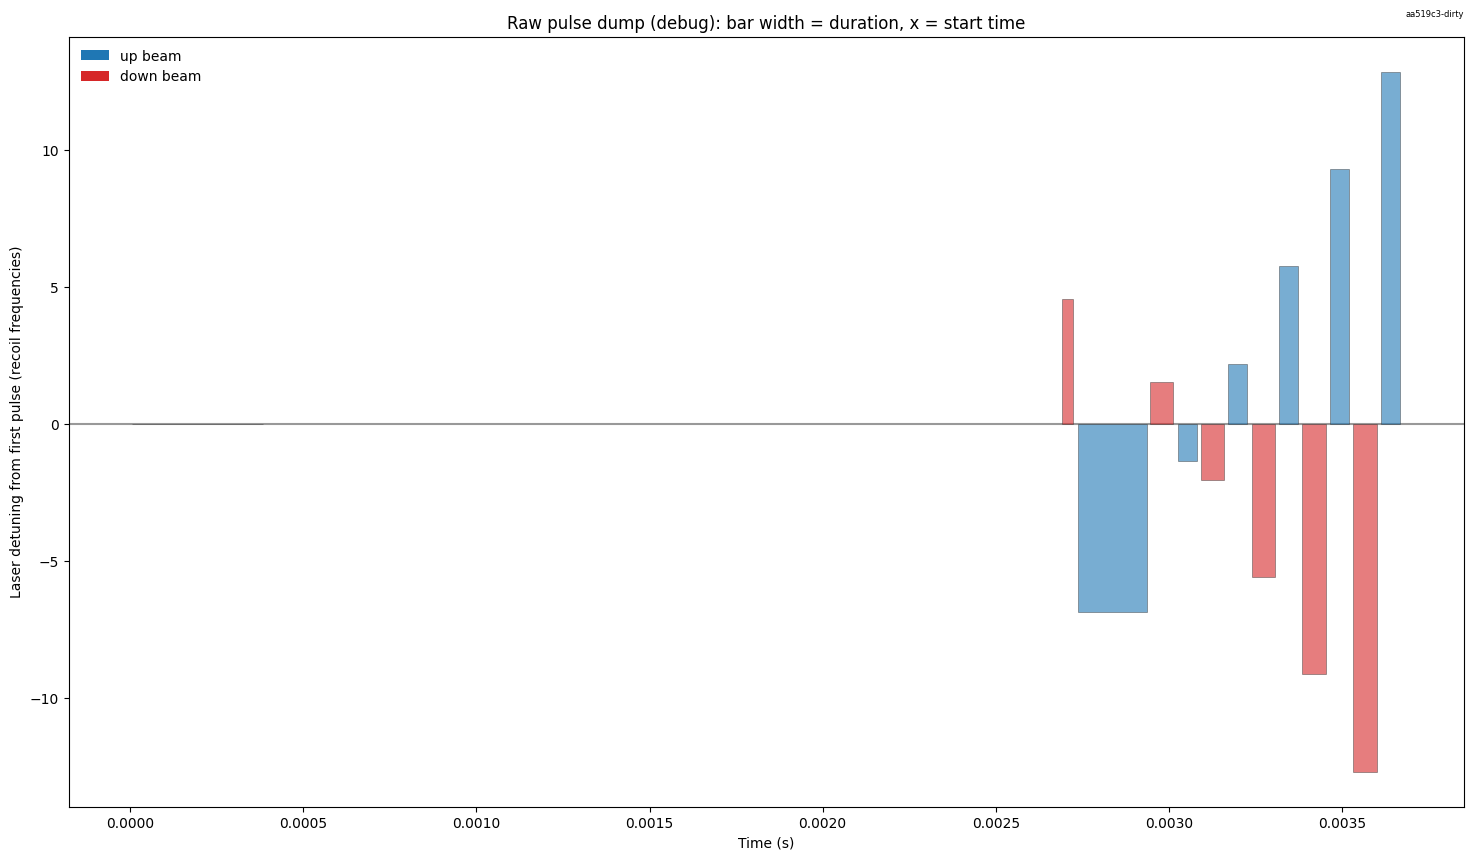

In [9]:
# --- DEBUG: raw pulse dump. Each recorded pulse is a bar at its true start time
# with WIDTH = duration, so overlapping pulses are visible. No gravity/Doppler
# compensation and no pi-pulse identification -- just the raw pulses, coloured by
# up/down beam.

_t = start_times_mu * 1e-9
_dur = durations_mu * 1e-9
_isup = is_up.astype(bool)

# Lab-frame laser detuning recentred on the first pulse (a constant offset --
# NOT gravity/Doppler compensation), just so the y-axis is legible in recoil
# units instead of spanning hundreds of MHz.
_detuning_recoil = (
    (-opll_hz - switch_hz - delivery_hz)
    - (-opll_hz[0] - switch_hz[0] - delivery_hz[0])
) / sim.RECOIL_FREQUENCY_HZ

fig, ax = plt.subplots(figsize=(18, 10))
for _s, _w, _y, _up in zip(_t, _dur, _detuning_recoil, _isup):
    ax.bar(
        _s, _y, width=_w, align="edge",
        color="tab:blue" if _up else "tab:red",
        alpha=0.6, edgecolor="0.2", linewidth=0.5, zorder=2,
    )
ax.axhline(0.0, color="0.5", linestyle="-", alpha=0.8, zorder=0)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Laser detuning from first pulse (recoil frequencies)")
ax.set_title("Raw pulse dump (debug): bar width = duration, x = start time")
ax.legend(
    handles=[
        Patch(facecolor="tab:blue", label="up beam"),
        Patch(facecolor="tab:red", label="down beam"),
    ],
    loc="upper left",
    frameon=False,
)
vs.tag_plot(small=True);

In [10]:
_, sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=initial_velocity_z,
    probe_induced_alpha_up=probe_shift_alpha,
    probe_induced_alpha_down=probe_shift_alpha,
)


## Mark the shaped velocity-selection pulse

The first pulse (380 us, up beam) is a shaped ("Jesse") velocity-selection pulse:
phase-shaped at FULL amplitude, so its true intensity -- and therefore its
probe-induced Stark shift -- corresponds to the same Rabi frequency as the ordinary
up pi pulses (~9.1 kHz), not the fictitious `1/(2*duration)` ~ 1.3 kHz that
`build_sequence_from_lab_pulse_dump` infers from its duration. The pulse-shaping
details are out of scope: we model it as a plain pi pulse and set
`stark_rabi_frequency` so the sim computes the light shift from the true intensity.

Because the shaped pulse is the **first** pulse, it is also the frequency anchor:
the parser derived the centre frequency from it using the fictitious Rabi
frequency, so every detuning in the sequence inherits the error in its probe
shift. We re-derive the anchor with the true Rabi frequency by shifting all
detunings by `alpha * (rabi_true**2 - rabi_fictitious**2)`.

N.B. the 200 us pulse is `JessePulseLMT` in icl_experiments -- also a full-amplitude
shaped pulse. It is NOT marked here (out of scope for now): note that as a plain
pi pulse its recorded frequency does not correspond to any single recoil rung, so
the inferred trajectory cannot follow the intended double-launch kick through it.

In [11]:
import dataclasses
from collections import Counter

pulses = [e for e in sequence if isinstance(e, seq.Pulse)]
shaped_pulse = pulses[0]
assert shaped_pulse.k == +1 and shaped_pulse.duration > 300e-6

rabi_counts = Counter(p.rabi_frequency for p in pulses[1:] if p.k == +1)
print("Rabi frequencies inferred for the other up pulses:")
for rabi, count in sorted(rabi_counts.items()):
    print(f"  {rabi:8.1f} Hz x {count}")
true_up_rabi = rabi_counts.most_common(1)[0][0]
print(f"-> using the most common as the shaped pulse's true Rabi: {true_up_rabi:.1f} Hz")
assert np.isclose(true_up_rabi, rabi_freq_ref, rtol=1e-3)

# The dump parser anchored the centre frequency on the first pulse being
# resonant after removing ITS probe shift -- computed from the fictitious
# duration-implied Rabi frequency. Re-derive the anchor with the true Rabi
# frequency: every detuning shifts by the difference in the first pulse's shift.
anchor_correction_hz = probe_shift_alpha * (
    true_up_rabi**2 - shaped_pulse.rabi_frequency**2
)
print(
    f"centre-frequency anchor correction: {anchor_correction_hz:+.1f} Hz "
    f"({anchor_correction_hz / sim.RECOIL_FREQUENCY_HZ:+.3f} recoils), "
    "applied to every pulse"
)

sequence = [
    (
        event
        if not isinstance(event, seq.Pulse)
        else dataclasses.replace(
            event,
            detuning_hz=event.detuning_hz + anchor_correction_hz,
            stark_rabi_frequency=true_up_rabi if event is shaped_pulse else None,
        )
    )
    for event in sequence
]


Rabi frequencies inferred for the other up pulses:
    2500.0 Hz x 1
    9090.9 Hz x 5
-> using the most common as the shaped pulse's true Rabi: 9090.9 Hz
centre-frequency anchor correction: -1037.1 Hz (-0.220 recoils), applied to every pulse


In [12]:
def plot_lab_pulse_sequence(plot_sequence, plot_corrected=True, plot_by_timestamp=False):
    raw_detunings_recoil = []
    corrected_detunings_recoil = []
    pulse_colours = []
    pulse_hatches = []
    clearout_links = []

    last_pulse_index = None
    clearout_since_last_pulse = False

    PULSE_STYLES = {
        #              colour          hatch
        (True, True): ("tab:orange", ""),  # up,   pi
        (True, False): ("tab:blue", "///"),  # up,   pi/2
        (False, True): ("tab:red", "\\\\"),  # down, pi
        (False, False): ("tab:purple", "xxx"),  # down, pi/2
    }

    timestamps = []
    pulse_durations = []
    now = 0.0
    for event in plot_sequence:
        if isinstance(event, seq.Clearout):
            clearout_since_last_pulse = True
            now += event.duration
            continue

        if not isinstance(event, seq.Pulse):
            now += event.duration
            continue

        timestamps.append(now + event.duration / 2)
        pulse_durations.append(event.duration)
        now += event.duration

        pulse_index = len(raw_detunings_recoil)
        raw_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
        probe_shift_hz = (
            event.probe_shift_coefficient * event.effective_stark_rabi_frequency**2
        )
        corrected_detunings_recoil.append(
            (event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ
        )

        colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
        pulse_colours.append(colour)
        pulse_hatches.append(hatch)

        if last_pulse_index is not None and clearout_since_last_pulse:
            clearout_links.append((last_pulse_index, pulse_index))

        last_pulse_index = pulse_index
        clearout_since_last_pulse = False

    pulse_indices = np.arange(len(raw_detunings_recoil))

    fig, ax = plt.subplots(figsize=(18, 10))
    plot_detunings = (
        corrected_detunings_recoil if plot_corrected else raw_detunings_recoil
    )

    x_axis = timestamps if plot_by_timestamp else pulse_indices

    bars = ax.bar(x_axis, plot_detunings, color=pulse_colours, width= pulse_durations if plot_by_timestamp else 0.9)
    for bar, hatch in zip(bars, pulse_hatches):
        bar.set_hatch(hatch)

    for left_index, right_index in clearout_links:
        ax.plot(
            [x_axis[left_index], x_axis[right_index]],
            [
                plot_detunings[left_index],
                plot_detunings[right_index],
            ],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            zorder=3,
        )

    if not plot_by_timestamp:
        tick_step = max(1, len(pulse_indices) // 20)
        ax.set_xticks(pulse_indices[::tick_step])
        ax.set_xlabel("Pulse index")
    else:
        ax.set_xlabel("Time (s)")
    ax.set_ylabel("Detuning (recoil frequencies)")

    # Show where the uncorrected (raw) detuning sat, for comparison.
    if plot_corrected:
        ax.scatter(
            x_axis,
            raw_detunings_recoil,
            facecolor="none",
            edgecolor="0.2",
            marker="o",
            s=40,
            zorder=4,
        )

    # Horizontal gridlines on the odd integers only.
    y_min, y_max = ax.get_ylim()
    odd_integers = np.arange(np.ceil(y_min), np.floor(y_max) + 1)
    odd_integers = odd_integers[odd_integers % 2 != 0]
    for y in odd_integers:
        ax.axhline(y, color="0.5", linestyle=":", alpha=0.8, zorder=0)
    ax.axhline(0.0, color="0.5", linestyle="-", alpha=0.8, zorder=0)

    legend_handles = [
        Patch(facecolor="tab:orange", hatch="", label="up, pi"),
        Patch(facecolor="tab:blue", hatch="///", label="up, pi/2"),
        Patch(facecolor="tab:red", hatch="\\\\", label="down, pi"),
        Patch(facecolor="tab:purple", hatch="xxx", label="down, pi/2"),
    ]
    if clearout_links:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="tab:green",
                linestyle=":",
                linewidth=2,
                label="clearout between pulses",
            )
        )

    ax.legend(handles=legend_handles, loc="upper left", frameon=False)

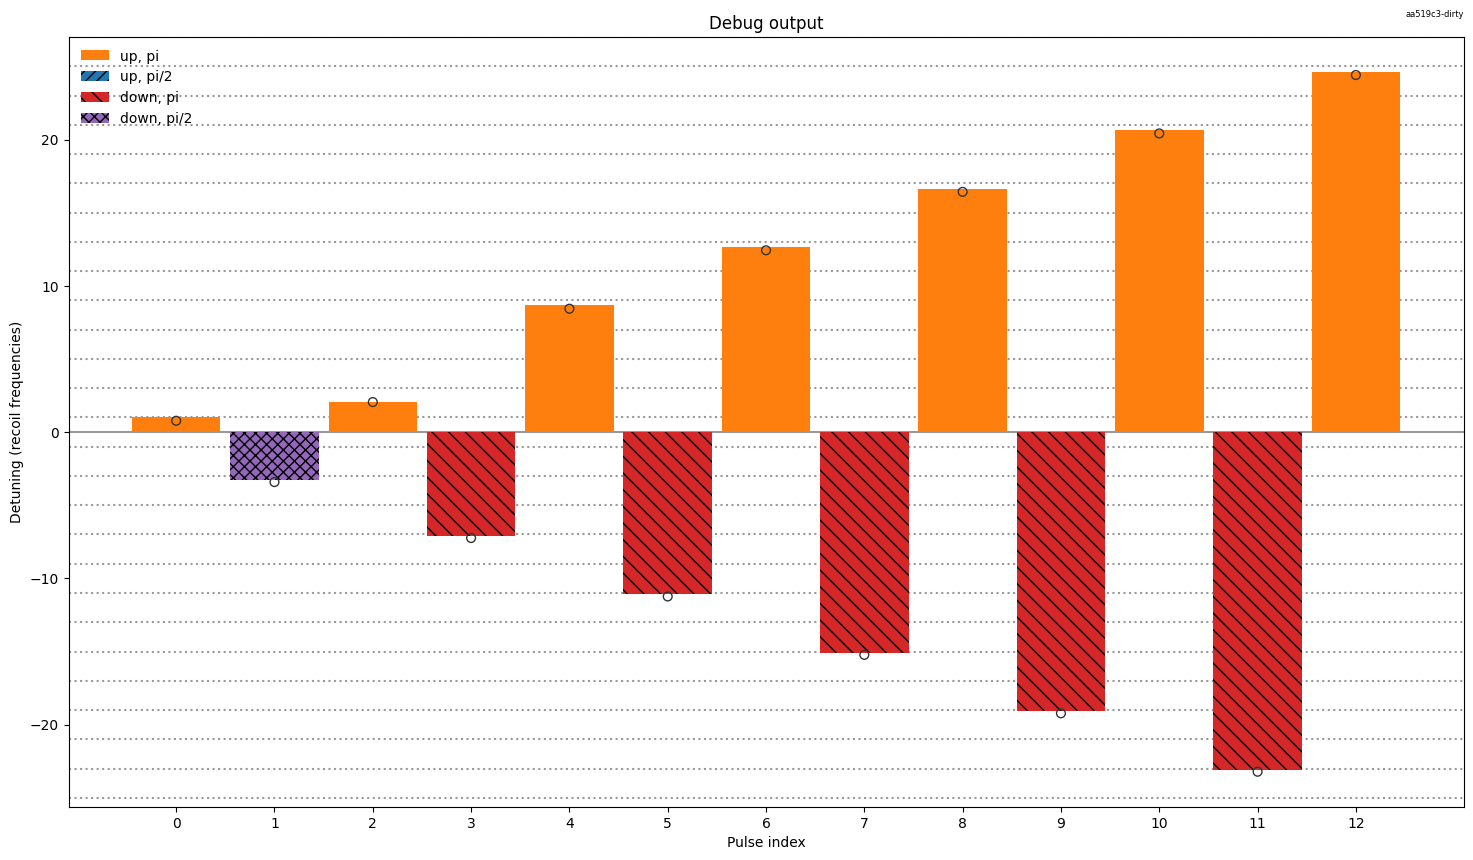

In [13]:
plot_lab_pulse_sequence(sequence, plot_corrected=True)
plt.title("Debug output")
vs.tag_plot(small=True);

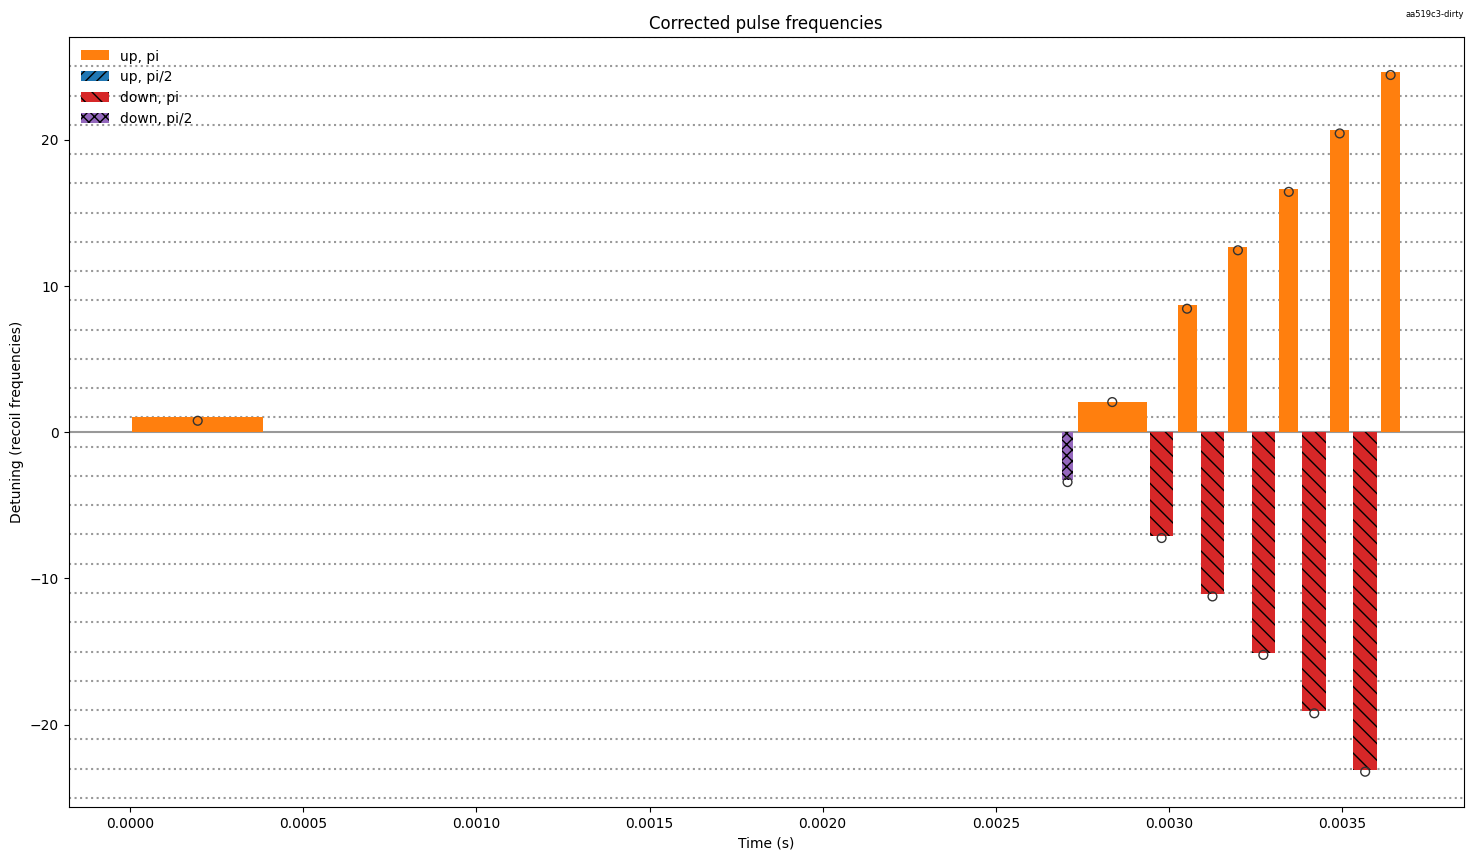

In [14]:
plot_lab_pulse_sequence(sequence, plot_corrected=True, plot_by_timestamp=True)
plt.title("Corrected pulse frequencies")
vs.tag_plot(small=True);

([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(4.936000000000001e-06), np.float64(0.000384936), np.float64(0.0026903989999999996), np.float64(0.0027243989999999997), np.float64(0.0027365429999999997), np.float64(0.002936543), np.float64(0.002945087), np.float64(0.003013087), np.float64(0.0030250859999999997), np.float64(0.0030800859999999997), np.float64(0.0030920849999999996), np.float64(0.0031600849999999995), np.float64(0.003172084), np.float64(0.003227084), np.float64(0.003239083), np.float64(0.0033070829999999997), np.float64(0.0033190819999999997), np.float64(0.0033740819999999996), np.float64(0.003386081), np.float64(0.003454081), np.float64(0.00346608), np.float64(0.0035210799999999998), np.float64(0.0035330789999999997), np.float64(0.0036010789999999997), np.float64(0.0036130779999999996), np.float64(0.0036680779999999995)], z=[0.0, np.float64(0.0), np.float64(2.4969845359566025e-06), np.float64(1.7646209428641116e-05), np.float64(1.7869623834489865e-05),

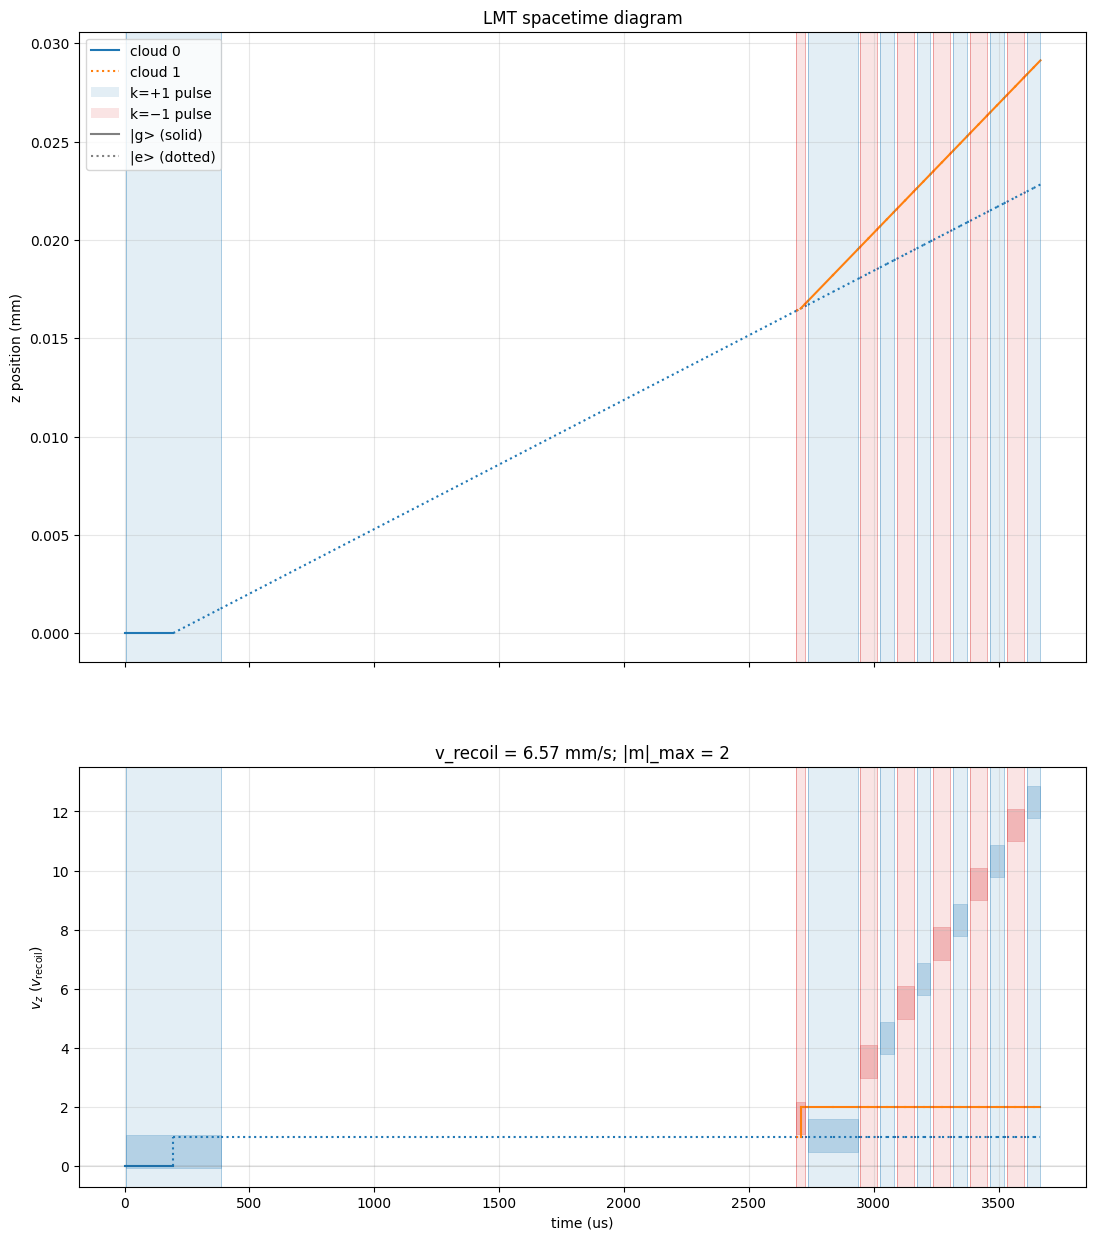

In [15]:
seq.compute_spacetime_trajectory(sequence, plot=True, max_branches=20)

In [16]:
# Apply a hacky correction - round each pulse to the nearest corrected integer number of recoils
import dataclasses

bodged_sequence = []
for event in sequence:
    if not isinstance(event, seq.Pulse):
        bodged_sequence.append(event)
        continue

    probe_shift_hz = (
        event.probe_shift_coefficient * event.effective_stark_rabi_frequency**2
    )

    closest_integer = int(
        round((event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ)
    )

    # Re-add the probe shift so that the EFFECTIVE detuning (the sim subtracts
    # the shift again during the pulse) lands exactly on the recoil ladder.
    new_pulse = dataclasses.replace(
        event,
        detuning_hz=closest_integer * sim.RECOIL_FREQUENCY_HZ + probe_shift_hz,
    )
    bodged_sequence.append(new_pulse)


([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(4.936000000000001e-06), np.float64(0.000384936), np.float64(0.0026903989999999996), np.float64(0.0027243989999999997), np.float64(0.0027365429999999997), np.float64(0.002936543), np.float64(0.002945087), np.float64(0.003013087), np.float64(0.0030250859999999997), np.float64(0.0030800859999999997), np.float64(0.0030920849999999996), np.float64(0.0031600849999999995), np.float64(0.003172084), np.float64(0.003227084), np.float64(0.003239083), np.float64(0.0033070829999999997), np.float64(0.0033190819999999997), np.float64(0.0033740819999999996), np.float64(0.003386081), np.float64(0.003454081), np.float64(0.00346608), np.float64(0.0035210799999999998), np.float64(0.0035330789999999997), np.float64(0.0036010789999999997), np.float64(0.0036130779999999996), np.float64(0.0036680779999999995)], z=[0.0, np.float64(0.0), np.float64(2.4969845359566025e-06), np.float64(1.7646209428641116e-05), np.float64(1.7869623834489865e-05),

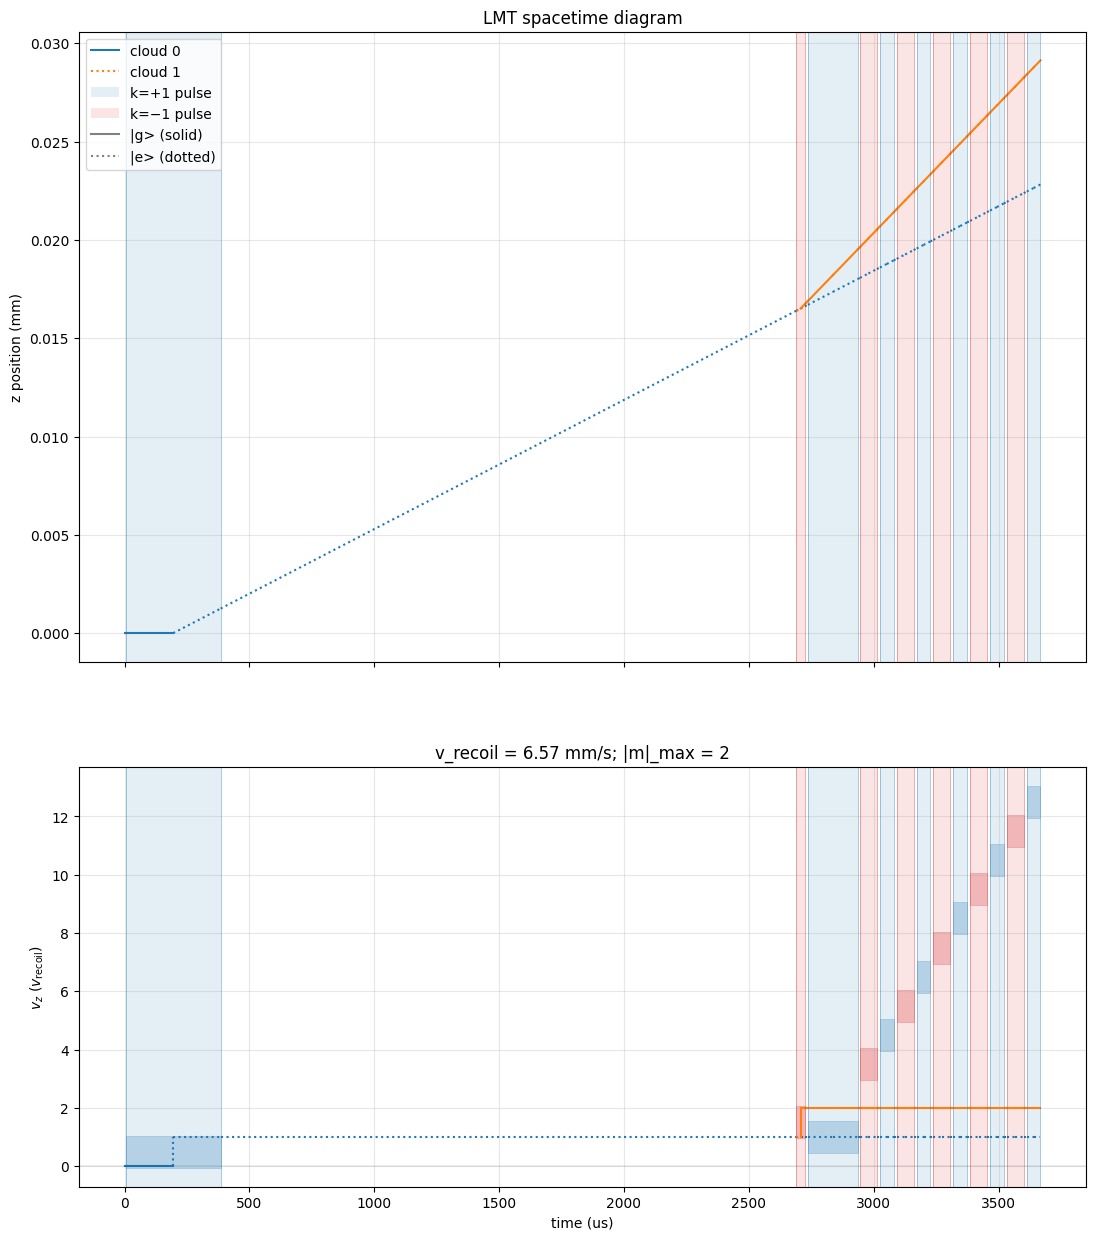

In [17]:
seq.compute_spacetime_trajectory(bodged_sequence, plot=True, max_branches=20)